# Code for plots Fig. 4

In [2]:
# import libraries
import numpy as np
import matplotlib
matplotlib.use("Qt5Agg")
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler
%matplotlib inline
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
import numpy.ma as ma
from sklearn.neighbors import NearestNeighbors
import datajoint as dj
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys,os,inspect

# import modules
from zeta_modulated import Neuron_modulated, Neuron_peths
from neuron_labels import Labels

currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
parentdir = os.path.dirname(currentdir)
sys.path.insert(0,parentdir)
from utilities import format_axs
print('hello')

hello


## Fig 4A 
Corresponds to schematic illustrations of ZETA method

## Fig 4B 
### Pie plot of neurons modulated by stimulus and/or choice onset

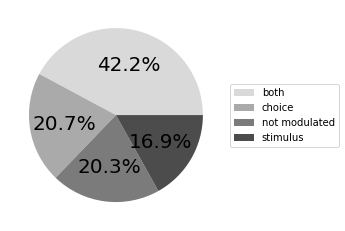

In [10]:
def plot_modulated_pie():
    def func(pct,data):
        return f"{pct:.1f}%"
    
    neuron_entries = Neuron_modulated()
    nr_neurons = len(neuron_entries)
    
    modulated = {}
    # not modulated
    not_modulated = neuron_entries & 'pval_stim>="0.05"' & 'pval_choice>="0.05"'
    modulated['not modulated'] = round(len(not_modulated)*100/nr_neurons,2)
    # stimulus modulated
    stimulus_modulated = neuron_entries & 'pval_stim<"0.05"' & 'pval_choice>="0.05"'
    modulated['stimulus'] = round(len(stimulus_modulated)*100/nr_neurons,2)
    # not modulated
    choice_modulated = neuron_entries & 'pval_stim>="0.05"' & 'pval_choice<"0.05"'
    modulated['choice'] = round(len(choice_modulated)*100/nr_neurons,2)
    # both stimulus and choice modulated
    both_modulated = neuron_entries & 'pval_stim<"0.05"' & 'pval_choice<"0.05"'
    modulated['both'] = round(len(both_modulated)*100/nr_neurons,2)
        
    # pie plot
    fig, axs = plt.subplots()
    fig.set_figwidth(9)
    fig.set_figheight(4)
    data = list(modulated.values())
    pie_labels = list(modulated.keys())
    
    # sort them according to percentage
    ziplists = sorted(zip(data,pie_labels),key=lambda x: x[0],reverse=True)
    sorted_data,sorted_labels = zip(*ziplists)
    
    colors = plt.cm.gray(np.linspace(0.3,0.85,len(sorted_labels)))[::-1]
    #colors = plt.cm.gray(np.linspace(0.4,0.95,int(len(sorted_labels)/2)))
    plt.rcParams['axes.prop_cycle'] = cycler(color=colors)

    wedges, texts, autotexts = axs.pie(sorted_data,autopct=lambda pct: func(pct,data),
                                      colors=colors,textprops={'fontsize': 20})

    axs.legend(wedges, sorted_labels,
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))

    plt.show()
    
plot_modulated_pie()

## Fig 4C 
### Examples of event onset responsive neurons. Averaged responses for each trial type and raster plots.

In [24]:
def neuron_profile_raster_plot(neuron_key):
    
    peths_entry = Neuron_peths() & neuron_key
    
    peths = peths_entry.fetch('peths')[0]
    combinations = peths_entry.fetch('combinations')[0]
    nr_combinations = len(combinations)
    nr_alignments = len(peths[0])
    nr_timepoints = len(peths[0][0][0])
    x_time = peths_entry.fetch('time')[0]
    
    colors_dict = {(1,0):'tab:cyan',
                   (0,1):'tab:olive',
                   (0,0):'tab:gray',
                   (1,1):'tab:orange'}
    
    alignments = ['stimulus','choice']
    assert len(alignments) == nr_alignments
    assert len(combinations) == nr_combinations
    
    fig, axs = plt.subplots(1,2)  
    fig.set_figwidth(6)
    fig.set_figheight(2.25)
    min_ax = []
    max_ax = []
    min_nr_trials = []
    for i,combination in enumerate(combinations):
        # print('combination',combination)
        combination_tuple=(combination[0],combination[1])
        for j,alignment in enumerate(alignments):
            min_nr_trials.append(len(peths[i][j]))
            vecMean = np.mean(peths[i][j],axis=0)
            assert len(vecMean) == nr_timepoints
            st = np.std(peths[i][j],axis=0)
            vecSem = st/np.sqrt(len(peths[i][j]))
            
            min_ax.append(np.min(vecMean-vecSem))
            max_ax.append(np.max(vecMean+vecSem))
            axs[j].plot(x_time, vecMean,color=colors_dict[combination_tuple])
            axs[j].axvline(x=0, color='black', linestyle='dashed')
            axs[j].fill_between(x_time, vecMean-vecSem, 
                                      vecMean+vecSem,alpha=0.2,
                                      color=colors_dict[combination_tuple])
            
                
            axs[j].spines["top"].set_visible(False)
            axs[j].spines["right"].set_visible(False)
            axs[j].spines["bottom"].set_linewidth(2)
            axs[j].spines["left"].set_linewidth(2)
            axs[j].set_xlabel('Time to %s onset (s)'%alignment)
            axs[j].set_ylabel('$\Delta F/ F$')
            axs[j].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
            if j == 1:
                axs[j].get_yaxis().set_visible(False)
                axs[j].spines["left"].set_visible(False)

    min_ax = np.min(min_ax) - 0.01
    max_ax = np.max(max_ax) + 0.01
    for ax in axs:
        ax.set_ylim(min_ax,max_ax)
        
    plt.tight_layout()
    plt.show()
    
    xticks = axs[j].get_xticks()[2:-2]
    tick_idx = [np.where(x_time> tick)[0][0] for tick in xticks]
    min_nr_trials = np.min(min_nr_trials)
    fig2, axs = plt.subplots(1,2)
    
    for j,alignment in enumerate(alignments):
        stacked = np.vstack([peths[i][j] for i in range(nr_combinations)])
        row_counter = 0
        for i,combination in enumerate(combinations):
            combination_tuple=(combination[0],combination[1])
            colormap = LinearSegmentedColormap.from_list('', [(0, "white"), (1, colors_dict[combination_tuple])])
            nr_trials = len(peths[i][j])
            indices = np.arange(nr_trials)
            np.random.shuffle(indices)
            shuffled = peths[i][j][indices]
            stacked[row_counter:row_counter+nr_trials] = shuffled
            masked_array = ma.masked_array(stacked, mask=np.zeros_like(stacked, dtype=bool))
            rows_to_unmask = [i for i in range(row_counter,row_counter+nr_trials,1)]
            for idx in range(len(stacked)):
                if idx not in rows_to_unmask:
                    masked_array[idx] = ma.masked
            row_counter += nr_trials
            axs[j].imshow(masked_array,interpolation='nearest',cmap=colormap,
                          vmin=min_ax+0.01,vmax=max_ax-0.01)
        axs[j].axvline(x=15, color='black', linestyle='dashed')
        axs[j].spines["top"].set_visible(False)
        axs[j].spines["right"].set_visible(False)
        axs[j].set_xticks(tick_idx)
        #axs[j].set_xticklabels([])
        axs[j].set_xlabel('Time to %s onset (s)'%alignment)
        axs[j].set_ylabel('# Trial')
        axs[j].spines["bottom"].set_linewidth(2)
        axs[j].spines["left"].set_linewidth(2)
        axs[j].invert_yaxis()

    plt.tight_layout()
    plt.show()
    return fig, fig2

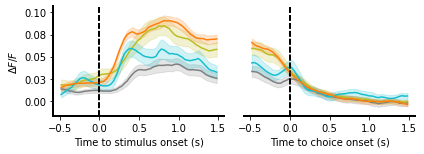

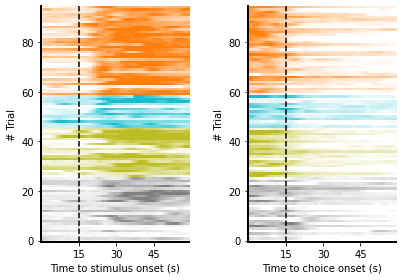

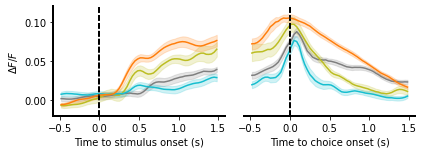

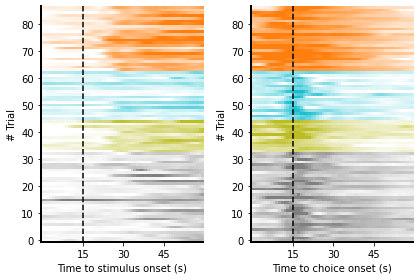

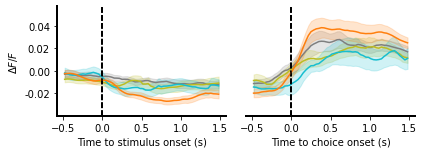

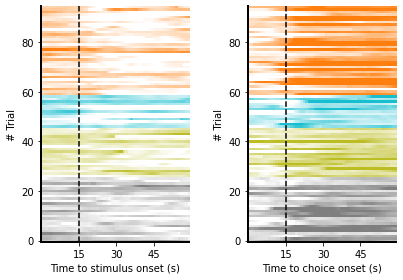

In [25]:
neuron_examples = [{'name': '1dsc_apr2023',
    'animal_id': 'BK4926_L',
    'mask_id': 152,
    'experimental_timepoint': 'categorization_4',
    'session_id': 53},
                   {'name': '1dsc_apr2023',
  'animal_id': 'BK4933_LR',
  'mask_id': 596,
  'experimental_timepoint': 'gentest_1',
  'session_id': 31},
                   {'name': '1dsc_apr2023',
   'animal_id': 'BK4926_L',
   'mask_id': 182,
   'experimental_timepoint': 'categorization_4',
   'session_id': 53}]

for neuron_key in neuron_examples:
    neuron_profile_raster_plot(neuron_key)

## Fig 4D
### Examples of event value selective neurons. Averaged responses for each trial type and corresponding raster plots.

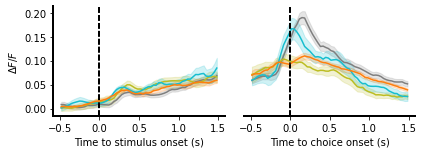

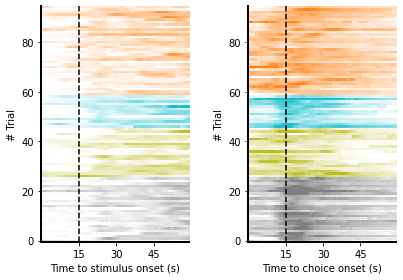

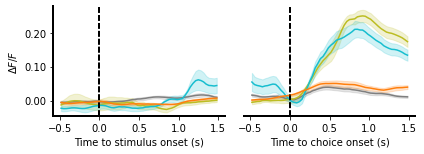

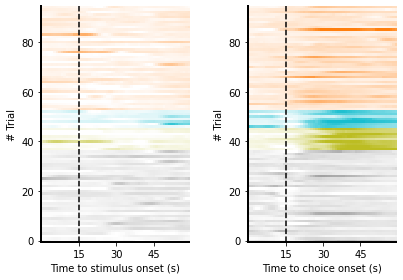

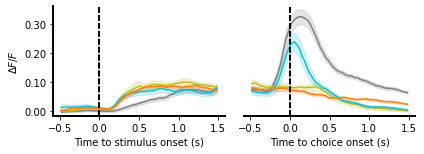

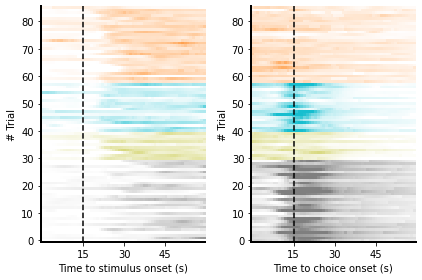

In [26]:
neuron_examples = [{'name': '1dsc_apr2023',
  'animal_id': 'BK4926_L',
  'mask_id': 519,
  'experimental_timepoint': 'categorization_4',
  'session_id': 53},
                   {'name': '1dsc_apr2023',
    'animal_id': 'BK4933_LR',
    'mask_id': 291,
    'experimental_timepoint': 'categorization_4',
    'session_id': 36},
                   {'name': '1dsc_apr2023',
    'animal_id': 'BK4926_L',
    'mask_id': 32,
    'experimental_timepoint': 'gentest_1',
    'session_id': 43}]

for neuron_key in neuron_examples:
    neuron_profile_raster_plot(neuron_key)

## Fig 4E
### t-SNE analysis on single-neuron activity profiles. Response profiles for different example neighbourhoods.

In [3]:
def get_mean_response_neighbourhood(cloud_keys):
    m_X = np.mean(X,1)
    st_X = np.std(X,1)
    peths = (Neuron_peths() & cloud_keys).fetch('peths')
    x_time = (Neuron_peths() & cloud_keys).fetch('time')[0]
    combinations = (Neuron_peths() & cloud_keys).fetch('combinations')[0]
    nr_timepoints = len(x_time)
    
    cloud_peths = []
    
    for c in range(4):
        peth_comb = []
        for window in range(2):
            peth_window = []
            for peth in peths:
                peth_window.append(peth[c][window])
            peth_window = np.vstack(peth_window)
            assert peth_window.shape[1] == nr_timepoints
            peth_comb.append(peth_window)
        cloud_peths.append(peth_comb)
    
    return cloud_peths,combinations,x_time
    
def plot_peth_profile(peths,combinations,x_time,title):
    nr_timepoints= len(x_time)
    nr_combinations = len(combinations)
    colors_dict = {(1,0):'tab:cyan',
                    (0,1):'tab:olive',
                    (0,0):'tab:gray',
                    (1,1):'tab:orange'}
    
    alignments = ['stimulus','choice']
    nr_alignments = len(alignments)
    assert len(peths) == nr_combinations
    assert len(peths[0]) == nr_alignments
    assert len(peths[0][0][0]) == nr_timepoints
    
    fig, axs = plt.subplots(1,2)  
    fig.set_figwidth(6)
    fig.set_figheight(2.25)
    min_ax = []
    max_ax = []
    min_nr_trials = []
    for i,combination in enumerate(combinations):
        # print('combination',combination)
        combination_tuple=(combination[0],combination[1])
        for j,alignment in enumerate(alignments):
            min_nr_trials.append(len(peths[i][j]))
            vecMean = np.mean(peths[i][j],axis=0)
            # print(vecMean.shape)
            assert len(vecMean) == nr_timepoints
            vecSt = np.std(peths[i][j],axis=0)
            vecSem = vecSt/np.sqrt(len(peths[i][j]))
            
            # print('pval',pval)
            min_ax.append(np.min(vecMean-vecSem))
            max_ax.append(np.max(vecMean+vecSem))
            axs[j].plot(x_time, vecMean,color=colors_dict[combination_tuple])
            axs[j].axvline(x=0, color='black', linestyle='dashed')
            axs[j].fill_between(x_time, vecMean-vecSem, 
                                      vecMean+vecSem,alpha=0.2,
                                      color=colors_dict[combination_tuple])
            
                
            axs[j].spines["top"].set_visible(False)
            axs[j].spines["right"].set_visible(False)
            axs[j].spines["bottom"].set_linewidth(2)
            axs[j].spines["left"].set_linewidth(2)
            axs[j].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
            if j == 1:
                axs[j].get_yaxis().set_visible(False)
                axs[j].spines["left"].set_visible(False)

    min_ax = np.min(min_ax) - 0.005
    max_ax = np.max(max_ax) + 0.005
    for ax in axs:
        ax.set_ylim(min_ax,max_ax)
        
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [4]:
# gather single neuron response profiles
neuron_keys = (Neuron_peths()).fetch(dj.key)

X = [] # nr neurons x response profile in window for combinations concatenated 
selected_keys = []
# concatenate responses for each trial type and window (event onset)
for i in tqdm(range(len(neuron_keys))):
    entry = Neuron_peths() & neuron_keys[i]
    
    label = (Labels & neuron_keys[i]).fetch('label')[0]
    if label != 'not modulated':
        entry = Neuron_peths() & neuron_keys[i]
        selected_keys.append(neuron_keys[i])
        peths = entry.fetch('peths')[0]
        time = entry.fetch('time')[0]
        
        vec_profile = []
        for c in range(4):
         # window alignments
            vec_windows = []
            for window in range(2):
                vec_windows.append(np.mean(peths[c][window],axis=0))
            vec_profile.append(np.concatenate(vec_windows))
            
        X.append(np.concatenate(vec_profile))
        
X=np.array(X)
print('X.shape',X.shape)
nr_neurons = X.shape[0]
#z scoring each neuron
m_X = np.mean(X,1)
st_X = np.std(X,1)
m_X = m_X[:,np.newaxis]
st_X = st_X[:,np.newaxis]
X_z = (X-m_X)/st_X

print('X_z.shape',X_z.shape)

# run pca on response profiles
pca = PCA(n_components=40) # 9 components explain > 80% variance
pca.fit(X_z.T)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
nr_components = np.where(cumulative_variance >0.95)[0][0] # 0.95
# restrict pca fit to components explaining 95% variance
pca = PCA(n_components=nr_components)
pca.fit(X_z.T)

pc_ = pca.components_
print('pc_',pc_.shape)
pc_time_profiles = pc_@ X_z

# define X (z scored) in new basis of principal components (profile in time)
X_pca = np.zeros_like(X_z)
for i in range(nr_neurons):
    neuron_pc = pc_[:,i] # neuron pc weights
    
    vec = neuron_pc @ pc_time_profiles
    X_pca[i] = vec
    
print('X_pca',X_pca.shape)

100%|██████████| 7936/7936 [03:03<00:00, 43.35it/s]


X.shape (6462, 480)
X_z.shape (6462, 480)
pc_ (21, 6462)
X_pca (6462, 480)


/home/lsainz/anaconda3/envs/berzotas/lib/python3.7/site-packages/ipykernel_launcher.py:30: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


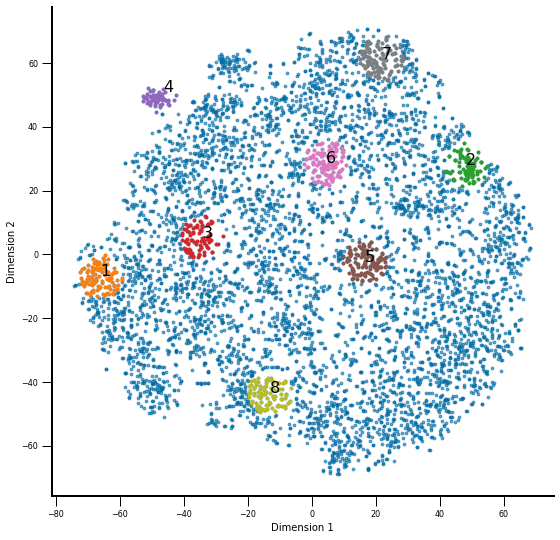

In [15]:
# Initialize t-SNE model
random_state=42
tsne_model = TSNE(n_components=2,n_iter=1000,random_state=random_state)

# Fit and transform the data to 2 dimensions for visualization
tsne_results = tsne_model.fit_transform(X_pca)

# run nearest neighbors on tSNE map to select example neighborhoods with given radius
nbrs = NearestNeighbors(n_neighbors=len(tsne_results), algorithm='ball_tree').fit(tsne_results)
radius = 7

target_points = [
       [-66.1,-6.8],
       [ 48.25023651,28.03405571],
       [-34.17747879,5.289186],
       [-46.5,51],
       [ 16.5,-2.3],
       [4.3,28.7],
       [21.7,61.4],
       [-13.0,-43.4]
       ]

points_neighbourhood = []

for target in target_points:
    target = np.array([target])
    distances, indices = nbrs.radius_neighbors(target, radius=radius)
    points_neighbourhood.append(indices[0])
    
points_neighbourhood = np.array(points_neighbourhood)

# plot neighbourhood in tsne map
cm = plt.cm.tab10
fig_tsne, ax = plt.subplots()
fig_tsne.set_figwidth(9)
fig_tsne.set_figheight(9)
ax.scatter(tsne_results[:, 0], tsne_results[:, 1],s=8, alpha=0.6)
ax = format_axs(ax)
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
    
for neighbourhood_idx,cloud in enumerate(points_neighbourhood):
    
    cloud_coords = tsne_results[cloud]
    ax.scatter(cloud_coords[:,0], cloud_coords[:,1],s=8,color=cm(neighbourhood_idx+1))
    ax.annotate(str(neighbourhood_idx + 1),xy=(target_points[neighbourhood_idx][0],
                                     target_points[neighbourhood_idx][1]),
                xycoords='data',fontsize=16)
plt.show()





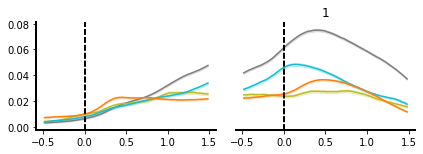

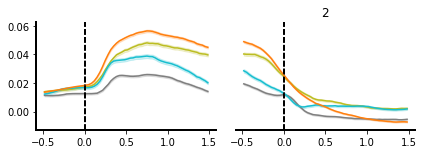

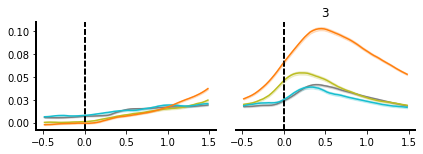

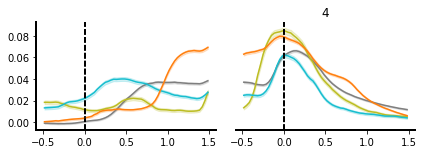

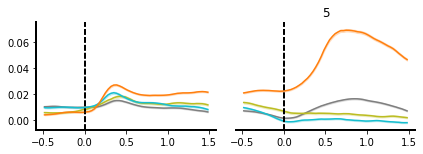

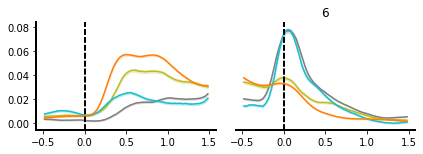

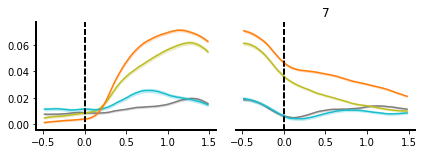

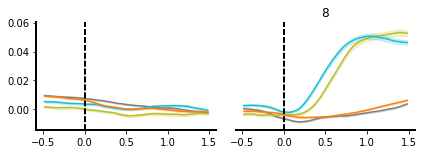

In [16]:
# plot average response of cells in neighbourhood

for neighbourhood_idx,cloud in enumerate(points_neighbourhood):
    
    cloud_keys = np.array(selected_keys)[cloud.tolist()]
    x_time = (Neuron_peths() & cloud_keys).fetch('time')[0]
    combinations = (Neuron_peths() & cloud_keys).fetch('combinations')[0]
    cloud_peths,combinations,x_time = get_mean_response_neighbourhood(cloud_keys)
    plot_peth_profile(cloud_peths,combinations,x_time,str(neighbourhood_idx+1))